# **AirBlocks: Next Generation Block Based Puzzle Games Through Computer Vision Based on Hand Gesture Tracking**

**Import Library**

In [51]:
import cv2
import pygame
import random
import mediapipe as mp

**Setup Color and Screen**

In [52]:
WHITE = (255, 255, 255)
BLACK = (0, 0, 0)
GRAY = (200, 200, 200)
BLUE = (50, 150, 255)
RED = (255, 50, 50)
GREEN = (50, 255, 50)
CYAN = (50, 255, 255)
MAGENTA = (255, 50, 255)
YELLOW = (255, 255, 50)
ORANGE = (255, 150, 50)
PURPLE = (150, 50, 255)
PINK = (255, 105, 180)
LIME = (150, 255, 50)
TEAL = (0, 128, 128)
BROWN = (139, 69, 19)
NAVY = (0, 0, 128)

SCREEN_WIDTH = 850
SCREEN_HEIGHT = 750
GRID_SIZE = 8
CELL_SIZE = 55
GRID_OFFSET_X = (SCREEN_WIDTH - (GRID_SIZE * CELL_SIZE)) // 2
GRID_OFFSET_Y = 50

**Setup Matrix**

In [53]:
ALL_SHAPES = [
    
    # 1.SQUARE
    {"matrix": [[1]], "color": RED},                               # 1x1
    {"matrix": [[1, 1], [1, 1]], "color": GREEN},                  # 2x2
    {"matrix": [[1, 1, 1], [1, 1, 1], [1, 1, 1]], "color": BLUE},  # 3x3

    # 2.LINE
    {"matrix": [[1, 1]], "color": CYAN},                           # 1x2 Horizontal
    {"matrix": [[1], [1]], "color": CYAN},                         # 2x1 Vertikal
    {"matrix": [[1, 1, 1]], "color": MAGENTA},                     # 1x3 Horizontal
    {"matrix": [[1], [1], [1]], "color": MAGENTA},                 # 3x1 Vertikal
    {"matrix": [[1, 1, 1, 1]], "color": YELLOW},                   # 1x4 Horizontal
    {"matrix": [[1], [1], [1], [1]], "color": YELLOW},             # 4x1 Vertikal

    # 3. Block "T"
    # T (4 Block)
    {"matrix": [[1, 1, 1], [0, 1, 0]], "color": ORANGE},           # T Normal (bawah)
    {"matrix": [[0, 1, 0], [1, 1, 1]], "color": ORANGE},           # T Terbalik (atas)
    {"matrix": [[1, 0], [1, 1], [1, 0]], "color": ORANGE},         # T Kiri
    {"matrix": [[0, 1], [1, 1], [0, 1]], "color": ORANGE},         # T Kanan

    # T (5 Block)
    {"matrix": [[1, 1, 1], [0, 1, 0], [0, 1, 0]], "color": PURPLE},# T Besar Normal
    {"matrix": [[0, 1, 0], [0, 1, 0], [1, 1, 1]], "color": PURPLE},# T Besar Terbalik
    {"matrix": [[1, 0, 0], [1, 1, 1], [1, 0, 0]], "color": PURPLE},# T Besar Kiri
    {"matrix": [[0, 0, 1], [1, 1, 1], [0, 0, 1]], "color": PURPLE},# T Besar Kanan

    # ==========================================
    # 4.Block "L"
    # L (3 Block)
    {"matrix": [[1, 0], [1, 1]], "color": PINK},                   # L 3-blok Kiri Bawah
    {"matrix": [[0, 1], [1, 1]], "color": PINK},                   # L 3-blok Kanan Bawah
    {"matrix": [[1, 1], [1, 0]], "color": PINK},                   # L 3-blok Kiri Atas
    {"matrix": [[1, 1], [0, 1]], "color": PINK},                   # L 3-blok Kanan Atas

    # L (4 Block | L and J)
    {"matrix": [[1, 0], [1, 0], [1, 1]], "color": LIME},           # L Normal
    {"matrix": [[1, 1, 1], [1, 0, 0]], "color": LIME},             # L Tidur Atas
    {"matrix": [[1, 1], [0, 1], [0, 1]], "color": LIME},           # L Terbalik
    {"matrix": [[0, 0, 1], [1, 1, 1]], "color": LIME},             # L Tidur Bawah

    {"matrix": [[0, 1], [0, 1], [1, 1]], "color": TEAL},           # J Normal (Cermin L)
    {"matrix": [[1, 0, 0], [1, 1, 1]], "color": TEAL},             # J Tidur Bawah
    {"matrix": [[1, 1], [1, 0], [1, 0]], "color": TEAL},           # J Terbalik
    {"matrix": [[1, 1, 1], [0, 0, 1]], "color": TEAL},             # J Tidur Atas

    # L (5 Block (3x3))
    {"matrix": [[1, 0, 0], [1, 0, 0], [1, 1, 1]], "color": BROWN}, # L Besar Kiri Bawah
    {"matrix": [[0, 0, 1], [0, 0, 1], [1, 1, 1]], "color": BROWN}, # L Besar Kanan Bawah
    {"matrix": [[1, 1, 1], [1, 0, 0], [1, 0, 0]], "color": BROWN}, # L Besar Kiri Atas
    {"matrix": [[1, 1, 1], [0, 0, 1], [0, 0, 1]], "color": BROWN}, # L Besar Kanan Atas

    # 5.Block "S" and "Z" (Zig-zag)
    # S and Z (4 Block)
    {"matrix": [[0, 1, 1], [1, 1, 0]], "color": NAVY},             # S Horizontal
    {"matrix": [[1, 0], [1, 1], [0, 1]], "color": NAVY},           # S Vertikal
    {"matrix": [[1, 1, 0], [0, 1, 1]], "color": NAVY},             # Z Horizontal (Cermin S)
    {"matrix": [[0, 1], [1, 1], [1, 0]], "color": NAVY},           # Z Vertikal
]

SPAWN_CENTERS = [(200, 615), (400, 615), (600, 615)]

**Hand Landmarks**

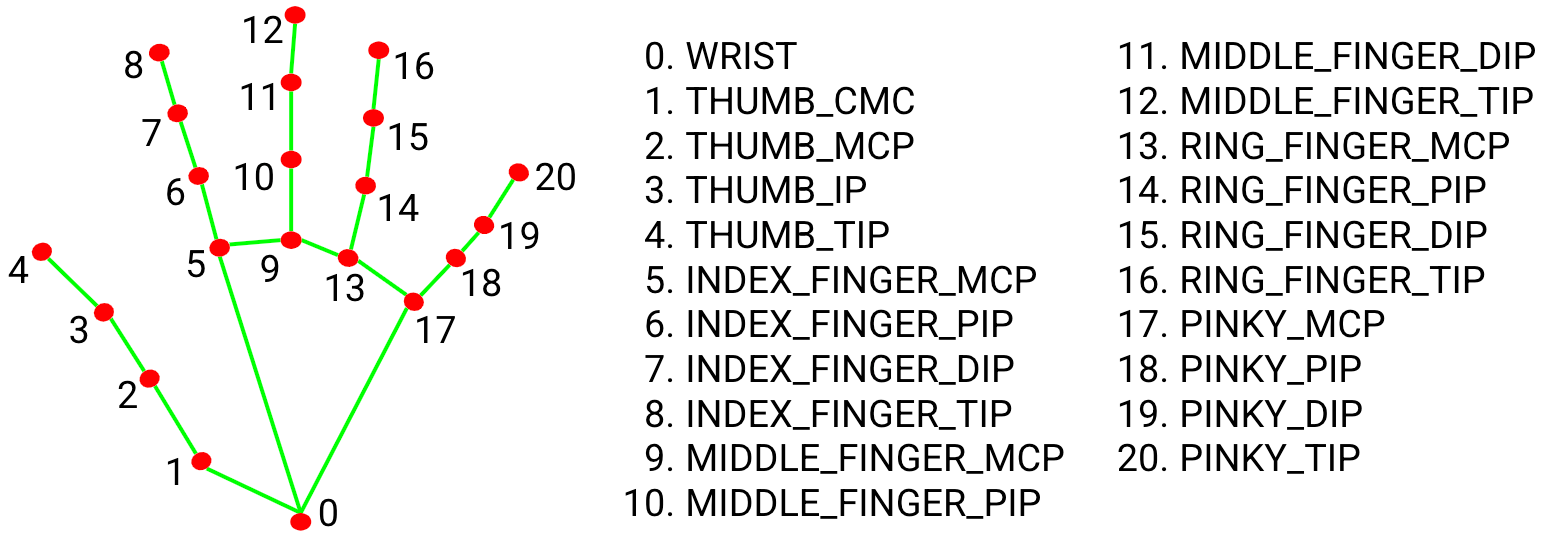

Initialization Mediapipe Hand Tracking

In [54]:
mp_hands = mp.solutions.hands
hands = mp_hands.Hands(max_num_hands=1, min_detection_confidence=0.7, min_tracking_confidence=0.7)
mp_draw = mp.solutions.drawing_utils

Logic of checking whether the hand is clenched (to grab) or open (to drop).

In [55]:
def get_hand_status(hand_landmarks): #Detects whether the hand is clenched or open (Y Coordinate)
    finger_tips = [8, 12, 16, 20] #Fingertip point (Index/Point, Middle, Sweet, Pinkie)
    finger_pips = [6, 10, 14, 18] #Base of lower finger
    
    fingers_folded = 0
    
    for tip, pip in zip(finger_tips, finger_pips): #Hand clenched
        if hand_landmarks.landmark[tip].y > hand_landmarks.landmark[pip].y:
            fingers_folded += 1
            
    if fingers_folded >= 3:
        return "CLOSED"
    else:
        return "OPEN"

def get_cursor_position(hand_landmarks): #Taking the base point of the middle finger (point 9) as the cursor
    x = int(hand_landmarks.landmark[9].x * SCREEN_WIDTH)
    y = int(hand_landmarks.landmark[9].y * SCREEN_HEIGHT)
    return x, y

**Grid & Block Logic**

Grid Logic

In [56]:
def create_empty_grid(): #Create an 8x8 matrix containing the number 0
    return [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]

def draw_grid(surface, grid): #Drawing a checkered board and blocks that are locked inside it
    for row in range(GRID_SIZE):
        for col in range(GRID_SIZE):
            rect = pygame.Rect(
                GRID_OFFSET_X + col * CELL_SIZE, 
                GRID_OFFSET_Y + row * CELL_SIZE, 
                CELL_SIZE, CELL_SIZE
            )
            pygame.draw.rect(surface, GRAY, rect, 1) # Border line
            
            if grid[row][col] != 0:
                pygame.draw.rect(surface, grid[row][col] , rect)
                pygame.draw.rect(surface, BLACK, rect, 1)

# Drwaing shape
def draw_shape(surface, matrix, start_x, start_y, color):
    rows = len(matrix)
    cols = len(matrix[0])
    offset_x = (cols * CELL_SIZE) // 2
    offset_y = (rows * CELL_SIZE) // 2
    
    for r in range(rows):
        for c in range(cols):
            if matrix[r][c] == 1:
                rect_x = start_x - offset_x + (c * CELL_SIZE)
                rect_y = start_y - offset_y + (r * CELL_SIZE)
                rect = pygame.Rect(rect_x, rect_y, CELL_SIZE, CELL_SIZE)
                pygame.draw.rect(surface, color, rect)
                pygame.draw.rect(surface, BLACK, rect, 1) # Black side line

# Generate 3 random blocks
def generate_3_options():
    options = []
    for center in SPAWN_CENTERS:
        shape_data = random.choice(ALL_SHAPES)
        options.append({
            "matrix": shape_data["matrix"],
            "color": shape_data["color"],
            "base_x": center[0],
            "base_y": center[1],
            "is_alive": True 
        })
    return options

Game Logic

In [57]:
def snap_to_grid(cursor_x, cursor_y): #Converts the free cursor coordinates to column and row indices in the Grid
    col = (cursor_x - GRID_OFFSET_X) // CELL_SIZE
    row = (cursor_y - GRID_OFFSET_Y) // CELL_SIZE
    return row, col

def is_placement_valid(grid, matrix, start_row, start_col):
    rows = len(matrix)
    cols = len(matrix[0])
    for r in range(rows):
        for c in range(cols):
            if matrix[r][c] == 1:
                target_row = start_row + r
                target_col = start_col + c
                if target_row < 0 or target_row >= GRID_SIZE or target_col < 0 or target_col >= GRID_SIZE:
                    return False
                if grid[target_row][target_col] != 0:
                    return False
    return True

def place_block_on_grid(grid, matrix, start_row, start_col, color):
    rows = len(matrix)
    cols = len(matrix[0])
    for r in range(rows):
        for c in range(cols):
            if matrix[r][c] == 1:
                grid[start_row + r][start_col + c] = color

def check_and_clear_lines(grid): 
    #Place to record the full row and column indexes
    full_rows = []
    full_cols = []
    
    # 1. CHECK HORIZONTAL (Row)
    for row in range(GRID_SIZE):
        if all(cell != 0 for cell in grid[row]):
            full_rows.append(row)
            
    # 2. CHECK VERTICAL (Column)
    for col in range(GRID_SIZE):
        if all(grid[row][col] != 0 for row in range(GRID_SIZE)):
            full_cols.append(col)
            
    lines_cleared = len(full_rows) + len(full_cols)
    
    # 3. DELETE EXECUTION (Concurrent)
    # Delete Row
    for row in full_rows:
        grid[row] = [0 for _ in range(GRID_SIZE)]
        
    # Delete Column
    for col in full_cols:
        for row in range(GRID_SIZE):
            grid[row][col] = 0

    return lines_cleared * 100 #100 point per line

def is_game_over(grid, available_blocks):
    for block in available_blocks:
        if block["is_alive"]:
            matrix = block["matrix"]
            for r in range(GRID_SIZE):
                for c in range(GRID_SIZE):
                    if is_placement_valid(grid, matrix, r, c):
                        return False 
                        
    if any(b["is_alive"] for b in available_blocks):
        return True 
        
    return False

**Run Game**

Initialize Pygame & Camera

In [58]:
pygame.init()
screen = pygame.display.set_mode((SCREEN_WIDTH, SCREEN_HEIGHT))
pygame.display.set_caption("AirBlocks: CV Hand Tracking Blocks Game")
clock = pygame.time.Clock()

font = pygame.font.SysFont("Poppins", 27)
go_font = pygame.font.SysFont("Poppins", 60)
btn_font = pygame.font.SysFont("Poppins", 30)

cap = cv2.VideoCapture(0)

Setup Game

In [59]:
grid_board = create_empty_grid()
score = 0
cursor_x, cursor_y = SCREEN_WIDTH // 2, SCREEN_HEIGHT // 2 # Default cursor position
current_gesture = "OPEN"

available_blocks = generate_3_options()
held_block_index = -1

spawn_area_rect = pygame.Rect(SCREEN_WIDTH//2 - CELL_SIZE//2, SCREEN_HEIGHT - 100, CELL_SIZE, CELL_SIZE)

Main Loop

In [60]:
game_state = "PLAYING"

retry_rect = pygame.Rect(270, 350, 140, 60)
exit_rect = pygame.Rect(430, 350, 140, 60)

running = True
while running:
    #A. EVENT HANDLING (Exit Button)
    for event in pygame.event.get():
        if event.type == pygame.QUIT:
            running = False
        elif event.type == pygame.KEYDOWN:
            if event.key == pygame.K_ESCAPE:
                running = False
            
    #B.OPENCV & MEDIAPIPE PROCESSING
    success, frame = cap.read()
    if not success:
        continue
        
    frame = cv2.flip(frame, 1) # Flip for better vision
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    results = hands.process(frame_rgb)
    
    cursor_x, cursor_y = -100, -100 
    current_gesture = "NONE" 
    
    if results.multi_hand_landmarks:
        for hand_landmarks in results.multi_hand_landmarks:
            cursor_x, cursor_y = get_cursor_position(hand_landmarks)
            current_gesture = get_hand_status(hand_landmarks)
            
            mp_draw.draw_landmarks(frame, hand_landmarks, mp_hands.HAND_CONNECTIONS)
            
    #C.GAME LOGIC
    if game_state == "PLAYING":
        # Logika 1: GRAB (Take the Block)
        if current_gesture == "CLOSED" and held_block_index == -1:
            for i in range(3):
                if available_blocks[i]["is_alive"]:
                    bx = available_blocks[i]["base_x"]
                    by = available_blocks[i]["base_y"]

                    if abs(cursor_x - bx) < 60 and abs(cursor_y - by) < 60:
                        held_block_index = i
                        break
                
        # Logic 2: Open Hands (DROP) after holding the block
        elif current_gesture == "OPEN" and held_block_index != -1:
            block_data = available_blocks[held_block_index]
            matrix = block_data["matrix"]
            
            offset_x_cells = len(matrix[0]) // 2
            offset_y_cells = len(matrix) // 2
            
            center_row, center_col = snap_to_grid(cursor_x, cursor_y)
            start_row = center_row - offset_y_cells
            start_col = center_col - offset_x_cells
            
            #Collision validation check
            if is_placement_valid(grid_board, matrix, start_row, start_col):
                place_block_on_grid(grid_board, matrix, start_row, start_col, block_data["color"])
                score += check_and_clear_lines(grid_board)
                available_blocks[held_block_index]["is_alive"] = False
                
            held_block_index = -1

            #Reload 3 blocks if all have been used
            if not any(b["is_alive"] for b in available_blocks):
                available_blocks = generate_3_options()

            if is_game_over(grid_board, available_blocks):
                game_state = "GAME_OVER"

    elif game_state == "GAME_OVER":
        if current_gesture == "CLOSED":
            if retry_rect.collidepoint(cursor_x, cursor_y):
                grid_board = [[0 for _ in range(GRID_SIZE)] for _ in range(GRID_SIZE)]
                score = 0
                available_blocks = generate_3_options()
                game_state = "PLAYING"
                pygame.time.delay(300)
                
            elif exit_rect.collidepoint(cursor_x, cursor_y):
                running = False

    #D.RENDERING (UI)
    screen.fill(WHITE)
    draw_grid(screen, grid_board)
    
    # Render UI Teks
    score_text = font.render(f"Score: {score}", True, BLACK)
    gesture_text = font.render(f"Gesture: {current_gesture}", True, BLACK)
    
    fps = int(clock.get_fps()) 
    fps_color = RED if fps < 20 else GREEN 
    fps_text = font.render(f"FPS: {fps}", True, fps_color)

    screen.blit(score_text, (20, 20))
    screen.blit(gesture_text, (20, 45))
    screen.blit(fps_text, (20, 70))
    
    if game_state == "PLAYING":
        for i in range(3):
            b = available_blocks[i]
            if b["is_alive"] and held_block_index != i:
                draw_shape(screen, b["matrix"], b["base_x"], b["base_y"], b["color"])
            
        if held_block_index != -1:
            b = available_blocks[held_block_index]
            draw_shape(screen, b["matrix"], cursor_x, cursor_y, b["color"])

    # UI GAME OVER
    elif game_state == "GAME_OVER":
        overlay = pygame.Surface((SCREEN_WIDTH, SCREEN_HEIGHT))
        overlay.set_alpha(200)
        overlay.fill(BLACK)
        screen.blit(overlay, (0, 0))
        
        go_text = go_font.render("The Game is Up!", True, WHITE)
        screen.blit(go_text, (SCREEN_WIDTH//2 - go_text.get_width()//2, 220))
        
        pygame.draw.rect(screen, GREEN, retry_rect, border_radius=10)
        pygame.draw.rect(screen, RED, exit_rect, border_radius=10)
        
        retry_text = btn_font.render("Retry", True, BLACK)
        exit_text = btn_font.render("Exit", True, WHITE)
        
        screen.blit(retry_text, (retry_rect.x + 43, retry_rect.y + 22))
        screen.blit(exit_text, (exit_rect.x + 50, exit_rect.y + 22))

    color_gesture = RED if current_gesture == "CLOSED" else (GREEN if current_gesture == "OPEN" else GRAY)
    if current_gesture != "NONE":
        pygame.draw.circle(screen, color_gesture, (cursor_x, cursor_y), 10)

    # Update Screen
    pygame.display.flip()
    cv2.imshow("Webcam - AirBlocks Engine", frame)
    clock.tick(30)

#E.CLEANUP
cap.release()
cv2.destroyAllWindows()
pygame.quit()